# Main Figures in Time-Series-SCF-Convergence Paper

Follow through this notebook you can reproduce all the figures presented in the paper

In [1]:
import os
import re
import pickle
import numpy as np
import pandas as pd
from pathlib import Path

# Plotting and Styling
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from matplotlib import rc
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator

# Analysis and Metrics
from scipy.signal import find_peaks
from statsmodels.tsa.stattools import acf
from sklearn.linear_model import LinearRegression
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, f1_score

### Figure 1. Distribution of SCF Iteration Counts for Doublet Anionic QM9 Molecules

In [5]:
# Load the data
data_path = os.path.join(Path.cwd().parents[0], "notebook_data", "iter_length_and_index_long_short_med.pkl")
with open(data_path, "rb") as file:
    iter_infos, difficult_index, easy_index, intermediate_index = pickle.load(file)

# Set global font and style for all plots
def _set_global_font():
    """Helper to enforce Arial Bold, size 8 everywhere."""
    rc('axes', linewidth=1)

    plt.rcParams['pdf.fonttype'] = 42   # Embed fonts as Truetype → editable text
    plt.rcParams['ps.fonttype'] = 42
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['font.size'] = 8
    plt.rcParams['font.weight'] = 'bold'
    plt.rcParams['axes.labelweight'] = 'bold'
    plt.rcParams['axes.titlesize'] = 8
    plt.rcParams['axes.labelsize'] = 8

    plt.rc('xtick', labelsize=8)
    plt.rc('ytick', labelsize=8)
    plt.rc('legend', fontsize=8)
    plt.rcParams['legend.title_fontsize'] = 8
    plt.rcParams['xtick.direction'] = 'in'
    plt.rcParams['ytick.direction'] = 'in'
    plt.rcParams['xtick.top'] = True
    plt.rcParams['ytick.right'] = True
    plt.rcParams['xtick.major.size'] = 3
    plt.rcParams['ytick.major.size'] = 3
    plt.rcParams['xtick.major.width'] = 0.8
    plt.rcParams['ytick.major.width'] = 0.8

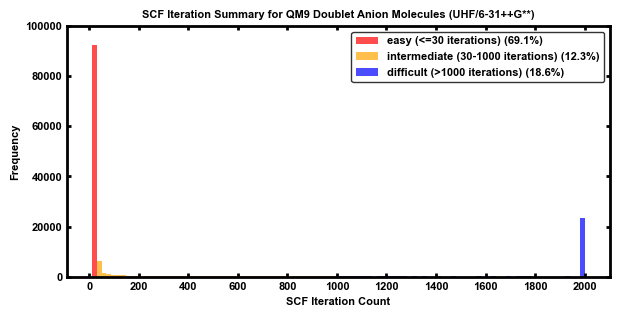

In [6]:
plt.figure(figsize=(7, 3.25))

_set_global_font()

easy = np.array(iter_infos)[easy_index]
difficult = np.array(iter_infos)[difficult_index]
intermediate = np.array(iter_infos)[intermediate_index]

counts = np.array([len(easy), len(intermediate), len(difficult)])
percentages = counts / counts.sum() * 100

# Plot histograms with color coding
plt.hist(easy, bins=1, color='red', alpha=0.7, label=f'easy (<=30 iterations) ({percentages[0]:.1f}%)')
plt.hist(intermediate, bins=50, color='orange', alpha=0.7, label=f'intermediate (30-1000 iterations) ({percentages[1]:.1f}%)')
plt.hist(difficult, bins=50, color='blue', alpha=0.7, label=f'difficult (>1000 iterations) ({percentages[2]:.1f}%)')

# Add labels and title
plt.title("SCF Iteration Summary for QM9 Doublet Anion Molecules (UHF/6-31++G**)", fontweight='bold')
plt.tick_params(axis='both', which='major',  width=2, direction='in', top=True, right=True)

xticks = np.arange(0, 2100, 200)
xlabels = [str(x) for x in xticks]
plt.xticks(xticks, xlabels)

plt.ylim(0, 10000)
yticks = np.arange(0, 105000, 20000)
ylabels = [str(y) for y in yticks]
plt.yticks(yticks, ylabels)

plt.xlabel("SCF Iteration Count")
plt.ylabel("Frequency")
lgnd = plt.legend(frameon=True, fontsize=8, loc="upper right")

# Make background fully transparent
lgnd.get_frame().set_facecolor('none')      
# Add black border
lgnd.get_frame().set_edgecolor('black')

for spine in plt.gca().spines.values():
    spine.set_linewidth(2)

plt.savefig("Figure_1.pdf", dpi=600, format="pdf", bbox_inches='tight')
# Show the plot
plt.show()

### Figure 2. Schematic Representation of the Machine Learning Feature Extraction Pipeline

In [7]:
#Helper function to parse the log files and extract the first n iterations of SCF data into a DataFrame for analysis.
def _parse_first_n_iterations(file_path, n_steps=11):
    """Parse first n SCF iteration rows into a DataFrame (numeric)."""
    start_flag = "*** Start SCF Iterations ***"
    data_lines = []
    collecting = False

    with open(file_path, "r", errors="ignore") as f:
        for line in f:
            if start_flag in line:
                collecting = True
                continue
            if collecting and re.match(r'^\|\s*\d+', line):
                data_lines.append(line.strip("| \n"))
                if len(data_lines) >= n_steps:
                    break

    if not data_lines:
        return pd.DataFrame()

    # Tokenize by whitespace
    split_data = [re.split(r"\s+", l.strip()) for l in data_lines]

    cols = [
        "Iter", "DIIS_Error", "Energy_change",
        "alphaHOMO-2", "alphaHOMO-1", "alphaHOMO", "alphaLUMO", "alphaLUMO+1", "alphaLUMO+2",
        "betaHOMO-2", "betaHOMO-1", "betaHOMO", "betaLUMO", "betaLUMO+1", "betaLUMO+2",
        "J", "K", "LA", "DFT", "Energy", "Time(s)"
    ]
    df = pd.DataFrame(split_data[1:], columns=cols)
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

In [15]:
# Data preparation for plotting
data_path = os.path.join(Path.cwd().parents[0], "notebook_data")
df = _parse_first_n_iterations(os.path.join(data_path, "figure_2_output_file.txt"))
df['alpha_frontier_gap'] = df['alphaLUMO'] - df['alphaHOMO']
df['beta_frontier_gap']  = df['betaLUMO']  - df['betaHOMO']
sample_a_gap = np.array(df['alpha_frontier_gap'])
x_coords = np.arange(len(sample_a_gap)) + 1

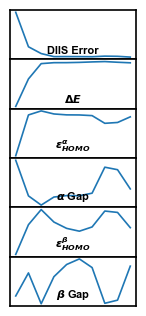

In [17]:
_set_global_font()

features_to_plot = [
    'DIIS_Error', 'Energy_change', 'alphaHOMO', 'alpha_frontier_gap', 'betaHOMO', 'beta_frontier_gap'
]

title_mapping = {
    'DIIS_Error': 'DIIS Error',
    'Energy_change': r'$\Delta E$',
    'alphaHOMO': r'$\epsilon^\alpha_{HOMO}$',
    'alpha_frontier_gap': r'$\alpha$ Gap',
    'betaHOMO': r'$\epsilon^\beta_{HOMO}$',
    'beta_frontier_gap': r'$\beta$ Gap'
}

fig, axes = plt.subplots(nrows=6, ncols=1, figsize=(1.5, 3.2), sharey=False, sharex=True, gridspec_kw={"wspace": 0, "hspace": 0})
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    ax = axes[i]
    
    # Plot Feature vs. Iteration
    ax.plot(df['Iter'], df[feature], linestyle='-', 
            color='tab:blue', linewidth=1.2)

    formatted_title = title_mapping.get(feature, feature)
    
    #ax.set_title(formatted_title, fontweight='bold')
    ax.text(0.5, 0.075, formatted_title, transform=ax.transAxes, ha='center', va='bottom', fontweight='bold')

    ax.set_xticks([])
    ax.set_yticks([])
        
    # Set the same thickness for all four sides
    ax.spines['top'].set_linewidth(1.2)
    ax.spines['right'].set_linewidth(1.2)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)

for j in range(len(features_to_plot), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("Figure_2_left.pdf", format='pdf', dpi=600, bbox_inches='tight')
plt.show()

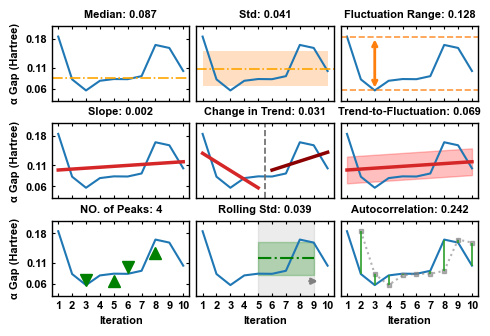

In [21]:
fig, axes = plt.subplots(3, 3, figsize=(5.5, 3.5), sharey=False, sharex=True, gridspec_kw={"wspace": 0.05, "hspace": 0.30})

_set_global_font()

maximum = np.max(sample_a_gap)
minimum = np.min(sample_a_gap)
mean = np.mean(sample_a_gap)

x_coords = np.arange(len(sample_a_gap)) + 1
sample_a_gap = np.array(df['alpha_frontier_gap'])
axes[0][0].plot(x_coords, sample_a_gap, color='tab:blue')
med = np.median(sample_a_gap)
axes[0][0].axhline(med, color='orange', linestyle='-.', linewidth=1.2)
axes[0][0].set_ylim(minimum - 0.025, maximum + 0.025)
axes[0][0].set_yticks([round(minimum, 2), round(mean, 2), round(maximum, 2)])
axes[0][0].tick_params(direction='in', length=2, left=True, top=True, right=True)
axes[0][0].set_title('Median: {:.3f}'.format(med), fontweight='bold')
axes[0][0].set_ylabel('α Gap (Hartree)', fontweight='bold')

axes[0][1].plot(x_coords, sample_a_gap, color='tab:blue')
mean = np.mean(sample_a_gap)
std = np.std(sample_a_gap)
axes[0][1].axhline(mean, color='orange', linestyle='-.', linewidth=1.2)
axes[0][1].fill_between(
        x_coords,
        np.clip(mean - std, 0, 1),
        np.clip(mean + std, 0, 1),
        color="tab:orange",
        alpha=0.25,
        linewidth=0,
    )
axes[0][1].set_ylim(minimum - 0.025, maximum + 0.025)
axes[0][1].set_yticks([])
axes[0][1].tick_params(direction='in', length=2, left=True, top=True, right=True)
axes[0][1].set_title('Std: {:.3f}'.format(std), fontweight='bold')

axes[0][2].plot(x_coords, sample_a_gap, color='tab:blue')
axes[0][2].axhline(y=np.max(sample_a_gap), color='tab:orange', linestyle='--', linewidth=1.2, alpha=0.8)
axes[0][2].axhline(y=np.min(sample_a_gap), color='tab:orange', linestyle='--', linewidth=1.2, alpha=0.8)

axes[0][2].annotate('', 
                 xy=(3.0, np.max(sample_a_gap)),      # Top of the arrow
                 xytext=(3.0, np.min(sample_a_gap)),  # Bottom of the arrow
                 arrowprops=dict(arrowstyle='<->', color='tab:orange', linewidth=2))
axes[0][2].set_ylim(minimum - 0.025, maximum + 0.025)
axes[0][2].set_yticks([])
axes[0][2].tick_params(direction='in', length=2, left=True, top=True, right=True) 
axes[0][2].set_title('Fluctuation Range: {:.3f}'.format(np.max(sample_a_gap) - np.min(sample_a_gap)), fontweight='bold')

axes[1][0].plot(x_coords, sample_a_gap, color='tab:blue')
x = (np.arange(len(sample_a_gap)) + 1).reshape(-1, 1)
reg = LinearRegression().fit(x, sample_a_gap)
trendline = reg.predict(x)
axes[1][0].plot(x, trendline, color='tab:red', linestyle='-', linewidth=2.5)
axes[1][0].set_ylim(minimum - 0.025, maximum + 0.025)
axes[1][0].set_yticks([round(minimum, 2), round(mean, 2), round(maximum, 2)])
axes[1][0].tick_params(direction='in', length=2, left=True, top=True, right=True) 
axes[1][0].set_ylabel('α Gap (Hartree)', fontweight='bold')
axes[1][0].set_title('Slope: {:.3f}'.format(reg.coef_[0]), fontweight='bold')

axes[2][1].plot(x_coords, sample_a_gap, color='tab:blue')
window_start = 5
window_end = 9
local_data = sample_a_gap[window_start:window_end+1]

local_mean = np.mean(local_data)
local_std = np.std(local_data, ddof=1) 

axes[2][1].axvspan(window_start, window_end, color='gray', alpha=0.15, zorder=0)

axes[2][1].hlines(local_mean, window_start, window_end, color='green', linestyle='-.', linewidth=1.5)

axes[2][1].fill_between([window_start, window_end], 
                     [local_mean - local_std]*2, 
                     [local_mean + local_std]*2, 
                     color='green', alpha=0.25)

axes[2][1].annotate('', xy=(9.5, local_mean*0.55), xytext=(8.5, local_mean*0.55),
                 arrowprops=dict(arrowstyle='->', linewidth=2, color='gray'))
axes[2][1].set_ylim(minimum - 0.025, maximum + 0.025)
axes[2][1].set_yticks([])
axes[2][1].tick_params(direction='in', length=2, left=True, top=True, right=True) 
axes[2][1].set_xlabel('Iteration', fontweight='bold')
axes[2][1].set_title('Rolling Std: {:.3f}'.format(local_std), fontweight='bold')

axes[2][0].plot(x_coords, sample_a_gap, color='tab:blue')
y_data = np.array(sample_a_gap) 
peaks, _ = find_peaks(y_data)
valleys, _ = find_peaks(-y_data) # Invert the data to find local minima
total_extrema = len(peaks) + len(valleys)

axes[2][0].plot(x_coords[peaks], y_data[peaks]*0.8, "^", color='green', 
             markersize=8, zorder=5)

axes[2][0].plot(x_coords[valleys], y_data[valleys]*1.2, "v", color='green', 
             markersize=8, zorder=5)
axes[2][0].set_ylim(minimum - 0.025, maximum + 0.025)
axes[2][0].set_yticks([round(minimum, 2), round(mean, 2), round(maximum, 2)])
axes[2][0].tick_params(direction='in', length=2, left=True, top=True, right=True) 
axes[2][0].set_title('NO. of Peaks: {}'.format(total_extrema), fontweight='bold')
axes[2][0].set_xlabel('Iteration', fontweight='bold')
axes[2][0].set_ylabel('α Gap (Hartree)', fontweight='bold')

axes[1][1].plot(x_coords, sample_a_gap, color='tab:blue')
mid_point = len(y_data) // 2

x1 = x_coords[:mid_point].reshape(-1, 1)
y1 = y_data[:mid_point]

x2 = x_coords[mid_point:].reshape(-1, 1)
y2 = y_data[mid_point:]

reg1 = LinearRegression().fit(x1, y1)
reg2 = LinearRegression().fit(x2, y2)

trend1 = reg1.predict(x1)
trend2 = reg2.predict(x2)

delta_trend = reg2.coef_[0] - reg1.coef_[0]

axes[1][1].plot(x_coords[:mid_point], trend1, color='tab:red', 
             linestyle='-', linewidth=2.5)
axes[1][1].plot(x_coords[mid_point:], trend2, color='darkred', 
             linestyle='-', linewidth=2.5)
# Add a vertical divider exactly in the middle (between index 4 and 5)
axes[1][1].axvline(x=mid_point + 0.5, color='dimgray', linestyle='--', linewidth=1.2)
axes[1][1].set_ylim(minimum - 0.025, maximum + 0.025)
axes[1][1].set_yticks([])
axes[1][1].set_xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
axes[1][1].tick_params(direction='in', length=2, left=True, top=True, right=True) 
axes[1][1].set_title('Change in Trend: {:.3f}'.format(delta_trend), fontweight='bold')

axes[1][2].plot(x_coords, sample_a_gap, color='tab:blue')

slope_val = reg.coef_[0]
rolling_std_val = pd.Series(sample_a_gap).rolling(window=5).std().mean()

# Plot the "Signal" (the slope line)
axes[1][2].plot(x, trendline, color='tab:red', linestyle='-', linewidth=2.5)

# Plot the "Noise" (the rolling std band around the slope)
axes[1][2].fill_between(x_coords, 
                     trendline - rolling_std_val, 
                     trendline + rolling_std_val, 
                     color='red', alpha=0.25)
axes[1][2].set_ylim(minimum - 0.025, maximum + 0.025)
axes[1][2].set_yticks([])
axes[1][2].set_xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
axes[1][2].tick_params(direction='in', length=2, left=True, top=True, right=True) 
axes[1][2].set_title('Trend-to-Fluctuation: {:.3f}'.format(abs(slope_val) / rolling_std_val if rolling_std_val > 0 else np.inf), fontweight='bold')

axes[2][2].plot(x_coords, sample_a_gap, color='tab:blue')

autocorr_values = acf(sample_a_gap, nlags=1)
lag_1_corr = autocorr_values[1] if len(autocorr_values) > 1 else 0

axes[2][2].plot(x_coords[1:], sample_a_gap[:-1], color='gray', linestyle=':', 
             marker='s', markersize=3, alpha=0.6, label='Lagged (t-1)')

# --- 4. Draw the Vertical Connection Lines ---
# These red dotted lines visually show the "gap" between the current step and the previous step
axes[2][2].vlines(x=x_coords[1:], 
               ymin=sample_a_gap[1:], 
               ymax=sample_a_gap[:-1], 
               color='tab:green', linestyle='-', linewidth=1.2)
axes[2][2].set_ylim(minimum - 0.025, maximum + 0.025)
axes[2][2].set_yticks([])
axes[2][2].set_xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
axes[2][2].set_xlabel('Iteration', fontweight='bold')
axes[2][2].set_title('Autocorrelation: {:.3f}'.format(lag_1_corr), fontweight='bold')
axes[2][2].tick_params(direction='in', length=2, left=True, top=True, right=True) 

plt.savefig("Figure_2_right.pdf", format='pdf', dpi=600, bbox_inches='tight')
plt.show()

### Figure 3. Window Size Selection

In [22]:
data_path = os.path.join(Path.cwd().parents[0], "notebook_data", "window_size_info.pkl")
with open(data_path, 'rb') as f:
    roc_auc_results = pickle.load(f)

roc_auc_small = roc_auc_results['small']
roc_auc_medium = roc_auc_results['medium']
roc_auc_large = roc_auc_results['large']

steps = np.linspace(6, 16, 11, dtype=int)

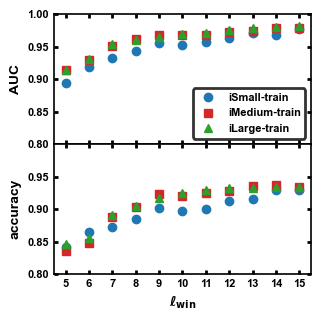

In [23]:
steps_arr = np.asarray(steps)

# === 2×1 stacked panels ===
fig, axes = plt.subplots(2, 1, figsize=(3.25, 3.25), sharex=True)

colors  = ['#1f77b4', '#d62728', '#2ca02c']
markers = ['o', 's', '^']
labels  = ['iSmall-train', 'iMedium-train', 'iLarge-train']

_set_global_font()

# ===========================
# TOP PANEL — AUC
# ===========================
ax = axes[0]
ax.plot(steps_arr - 1, [x[1] for x in roc_auc_small],
        marker=markers[0], color=colors[0],
        markersize=6, linestyle='none', label=labels[0])
ax.plot(steps_arr - 1, [x[1] for x in roc_auc_medium],
        marker=markers[1], color=colors[1],
        markersize=6, linestyle='none', label=labels[1])
ax.plot(steps_arr - 1, [x[1] for x in roc_auc_large],
        marker=markers[2], color=colors[2],
        markersize=6, linestyle='none', label=labels[2])

ax.set_ylabel("AUC", fontsize=10, fontweight='bold')
ax.set_ylim(0.80, 1.00)
ax.tick_params(axis="both", labelsize=8, direction='in', width=2,
               bottom=True, top=True, left=True, right=True)
lgnd = ax.legend(frameon=True, fontsize=8, loc="lower right")

# Make background fully transparent
lgnd.get_frame().set_facecolor('none')      

# Add black border
lgnd.get_frame().set_edgecolor('black')
lgnd.get_frame().set_linewidth(2)

# ===========================
# BOTTOM PANEL — Accuracy
# ===========================
ax = axes[1]
ax.plot(steps_arr - 1, [x[2] for x in roc_auc_small],
        marker=markers[0], color=colors[0],
        markersize=6, linestyle='none')
ax.plot(steps_arr - 1, [x[2] for x in roc_auc_medium],
        marker=markers[1], color=colors[1],
        markersize=6, linestyle='none')
ax.plot(steps_arr - 1, [x[2] for x in roc_auc_large],
        marker=markers[2], color=colors[2],
        markersize=6, linestyle='none')

ax.set_ylabel("accuracy", fontsize=10, fontweight='bold')
ax.set_xlabel(r"$\ell_{\mathrm{win}}$", fontsize=10, fontweight='bold')
ax.set_ylim(0.80, 1.00)
ax.set_yticks(np.arange(0.80, 1.00, 0.05))
ax.set_xticks(steps_arr - 1)
ax.tick_params(axis="both", labelsize=8, direction='in', width=2, 
               bottom=True, top=True, left=True, right=True)

# ===========================
# Remove grid + add thicker borders
# ===========================
for ax in axes:
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)   # thicker borders
        spine.set_edgecolor("black")

plt.tight_layout()
plt.subplots_adjust(hspace=0) 
plt.savefig("Figure_3.pdf", dpi=600, format='pdf', bbox_inches='tight')
plt.show()

### Figure 4. Evaluation of Threshold Calibration for the GBC Model Across Training Sets

In [26]:
# -------------------------------
# Function to predict with threshold
# -------------------------------
def predict_with_threshold(model, X, thr):
    pos_index = int(np.where(model.classes_ == 1)[0][0])
    p = model.predict_proba(X)[:, pos_index]
    return (p >= thr).astype(int), p

large_path = os.path.join(Path.cwd().parents[0], "notebook_data", "gb_large_xtest_xval.pkl")
med_path = os.path.join(Path.cwd().parents[0], "notebook_data", "gb_med_xtest_xval.pkl")
small_path = os.path.join(Path.cwd().parents[0], "notebook_data", "gb_small_xtest_xval.pkl")

with open(large_path, "rb") as file:
    [X_test_l, X_val_l, y_test_l, y_val_l] = pickle.load(file)
with open(med_path, "rb") as file:
    [X_test_m, X_val_m, y_test_m, y_val_m] = pickle.load(file)
with open(small_path, "rb") as file:
    [X_test_s, X_val_s, y_test_s, y_val_s] = pickle.load(file)

iSmall_path = os.path.join(Path.cwd().parents[0], "Models", "iSmall_model.pkl")
iMedium_path = os.path.join(Path.cwd().parents[0], "Models", "iMedium_model.pkl")
iLarge_path = os.path.join(Path.cwd().parents[0], "Models", "iLarge_model.pkl")

with open(iSmall_path, "rb") as file:
    gb_iSmall = pickle.load(file)

with open(iMedium_path, "rb") as file:
    gb_iMed = pickle.load(file)

with open(iLarge_path, "rb") as file:
    gb_iLarge = pickle.load(file)

thr_s = 0.741
thr_m = 0.802
thr_l = 0.834

In [27]:
# Small
y_pred_s, p_s = predict_with_threshold(gb_iSmall, X_test_s, thr_s)
cm   = confusion_matrix(y_test_s, y_pred_s)

# Medium
y_pred_m, p_m = predict_with_threshold(gb_iMed,  X_test_m, thr_m)
cm_2 = confusion_matrix(y_test_m, y_pred_m)

# Large
y_pred_l, p_l = predict_with_threshold(gb_iLarge, X_test_l, thr_l)
cm_3 = confusion_matrix(y_test_l, y_pred_l)

print(f"CM (iSmall @ {thr_s}):\n", cm)
print(f"CM_2 (iMed @ {thr_m}):\n", cm_2)
print(f"CM_3 (iLarge @ {thr_l}):\n", cm_3)

f1_s = f1_score(y_test_s, y_pred_s)
f1_m = f1_score(y_test_m, y_pred_m)
f1_l = f1_score(y_test_l, y_pred_l)

CM (iSmall @ 0.741):
 [[44426  1454]
 [ 2084  9921]]
CM_2 (iMed @ 0.802):
 [[42519  1361]
 [ 1429  8576]]
CM_3 (iLarge @ 0.834):
 [[40390   990]
 [ 1142  6363]]


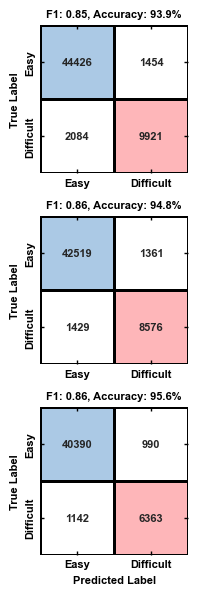

In [30]:
class_names = ["Easy", "Difficult"]

# --- define colors ---
TN_COLOR = "#abc9e5"   # top-left
TP_COLOR = "#feb6b9"   # bottom-right
OFF_COLOR = "#ffffff"  # for FP and FN (off-diagonal)

# indices: 0 = TN, 1 = FP, 2 = FN, 3 = TP
color_idx = np.array([[0, 1],
                      [2, 3]])

cmap = ListedColormap([TN_COLOR, OFF_COLOR, OFF_COLOR, TP_COLOR])
norm = BoundaryNorm(np.arange(-0.5, 4.5, 1), cmap.N)

_set_global_font()

fig, axes = plt.subplots(3, 1, figsize=(3.25, 6))

_set_global_font()

# ---- Small ----
sns.heatmap(
    color_idx,
    annot=cm, fmt='d',
    cmap=cmap, norm=norm,
    cbar=False, ax=axes[0], square=True,
    xticklabels=class_names, yticklabels=class_names, linewidths=1, linecolor='black',
    annot_kws={"size": 8}
)
axes[0].set_title(f"F1: {f1_s:.2f}, Accuracy: {cm.trace() / cm.sum() * 100:.1f}%", fontweight='bold')
axes[0].set_ylabel("True Label")
axes[0].tick_params(axis='both', which='major', width=1, direction='in',
                    left=True, bottom=True, top=True, right=True)

# ---- Medium ----
sns.heatmap(
    color_idx,
    annot=cm_2, fmt='d',
    cmap=cmap, norm=norm,
    cbar=False, ax=axes[1], square=True,
    xticklabels=class_names, yticklabels=class_names, linewidths=1, linecolor='black',
    annot_kws={"size": 8}
)
axes[1].set_title(f"F1: {f1_m:.2f}, Accuracy: {cm_2.trace() / cm_2.sum() * 100:.1f}%", fontweight='bold')
axes[1].set_ylabel("True Label")
axes[1].tick_params(axis='both', which='major', width=1, direction='in',
                    left=True, bottom=True, top=True, right=True)

# ---- Large ----
sns.heatmap(
    color_idx,
    annot=cm_3, fmt='d',
    cmap=cmap, norm=norm,
    cbar=False, ax=axes[2], square=True,
    xticklabels=class_names, yticklabels=class_names, linewidths=1, linecolor='black',
    annot_kws={"size": 8}
)

axes[2].set_title(f"F1: {f1_l:.2f}, Accuracy: {cm_3.trace() / cm_3.sum() * 100:.1f}%", fontweight='bold')
axes[2].set_xlabel("Predicted Label")
axes[2].set_ylabel("True Label")
axes[2].tick_params(axis='both', which='major', width=1, direction='in',
                    left=True, bottom=True, top=True, right=True)

plt.tight_layout()
plt.savefig("Figure_4_left.pdf", dpi=600, format='pdf', bbox_inches='tight')
plt.show()

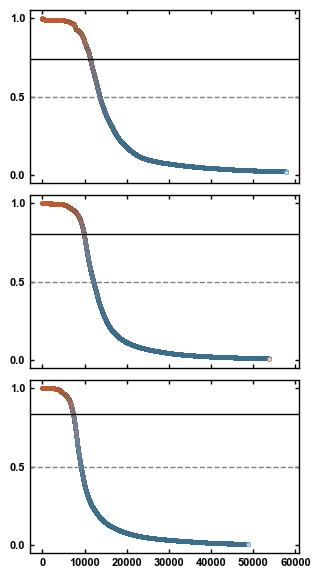

In [32]:
p_s = gb_iSmall.predict_proba(X_test_s)[:, 1]
p_m = gb_iMed.predict_proba(X_test_m)[:, 1]
p_l = gb_iLarge.predict_proba(X_test_l)[:, 1]

order_s = np.argsort(-p_s) # p_s are predicted probabilities
p_s_sorted = p_s[order_s]
y_s_sorted = y_test_s[order_s]
order_m = np.argsort(-p_m) # p_m are predicted probabilities
p_m_sorted = p_m[order_m]
y_m_sorted = y_test_m[order_m]
order_l = np.argsort(-p_l) # p_l are predicted probabilities
p_l_sorted = p_l[order_l]
y_l_sorted = y_test_l[order_l]

# Colors for short (0) and long (1)
face_short = "#acddff"
edge_short = "#3b6d8c"
face_long  = "#fbc7af"
edge_long  = "#c55b34"

def plot_prob_panel(ax, p, y_true, thr, title):
    # Sort by probability (descending)
    order = np.argsort(p)[::-1]
    p_sorted = p[order]
    y_sorted = y_true[order]

    # Build colors
    face_cols = [face_short if y == 0 else face_long for y in y_sorted]
    edge_cols = [edge_short if y == 0 else edge_long for y in y_sorted]

    ax.scatter(
        range(len(p_sorted)),
        p_sorted,
        facecolors=face_cols,
        edgecolors=edge_cols,
        linewidths=0.15,
        s=8,
    )

    # Baseline 0.5 and tuned threshold
    ax.axhline(0.5,  color="gray", linestyle="--", linewidth=1 )
    ax.axhline(thr,  color="black", linestyle="-", linewidth=1)

    ax.tick_params(
        axis="both", which="major", width=1, direction="in",
        left=True, bottom=True, top=True, right=True
    )
    ax.set_ylim(-0.05, 1.05)
    ax.set_yticks([0.0, 0.5, 1.0])
    ax.grid(False)

# ---------- 3×1 stacked figure ----------
fig, axes = plt.subplots(3, 1, figsize=(3.25, 6), sharex=True, sharey=True)

plot_prob_panel(axes[0], p_s, y_test_s, thr_s, "iSmall-test")
plot_prob_panel(axes[1], p_m, y_test_m, thr_m, "iMedium-test")
plot_prob_panel(axes[2], p_l, y_test_l, thr_l, "iLarge-test")

# Consistent borders
for ax in axes:
    for spine in ax.spines.values():
        spine.set_linewidth(1)
        spine.set_edgecolor("black")


plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("Figure_4_right.pdf", dpi=600, format='pdf', bbox_inches='tight')
plt.show()

### Figure 5. t-SNE Projection of Feature Space Distributions for Static Approach

In [12]:
data_path = os.path.join(Path.cwd().parents[0], "notebook_data", "domain_data_static.pkl")
with open(data_path, "rb") as file:
    (X, y, domain_all_static) = pickle.load(file)

DOMAIN_NAMES_DEFAULT = {
    0: "iQM40-default",
    1: "iQM40-DFT",
    2: "iQM9-default",
    3: "iQM9-larger-basis",
    4: "iQM9-hcore",
    5: "iQM9-PySCF",
}

In [8]:
def prepare_tsne_df(
    X, y, domain_all, domain_names=None,
    perplexity=30, n_iter=1000, random_state=42
):
    assert len(X) == len(y) == len(domain_all), "X, y, domain_all must align"
    
    emb = _safe_tsne(X, perplexity=perplexity, n_iter=n_iter, random_state=random_state)
    names = DOMAIN_NAMES_DEFAULT if domain_names is None else domain_names
    
    y_arr = np.array(y).astype(int)
    domain_arr = np.array(domain_all).astype(int)
    
    return pd.DataFrame({
        "tsne_x": emb[:, 0],
        "tsne_y": emb[:, 1],
        "label": y_arr,
        "domain_id": domain_arr,
        "domain": [names.get(d, f"domain_{d}") for d in domain_arr],
    })

def _safe_tsne(X, perplexity=30, n_iter=1000, random_state=42):
    n = len(X)
    perp = max(5, min(perplexity, max(5, n // 50)))
    perp = min(perp, max(5, (n - 1) // 3)) if n > 10 else 5
    
    # Ensure X is passed through StandardScaler() before reaching this function!
    tsne = TSNE(
        n_components=2, init="pca", learning_rate="auto",
        perplexity=perp, max_iter=n_iter, random_state=random_state
    )
    return tsne.fit_transform(X)

def _scatter(ax, df, color, marker, s=26, alpha=0.9):
    if df.empty: 
        return
    ax.scatter(
        df["tsne_x"], df["tsne_y"],
        c=color, marker=marker, s=s, alpha=alpha,
        edgecolors="black", linewidth=0.3
    )

def get_tsne_plots(X, y, domain_all, file_path=None):
    domain_names = ["iQM40-default ", "iQM40-DFT", "iQM9-default", "iQM9-large-basis", "iQM9-hcore", "iQM9-PySCF"]

    # --- 1. MINIMAL CHANGE: Downsample the 63K training set to balance t-SNE ---
    domain_array = np.array(domain_all)
    train_idx = np.where(domain_array == 6)[0]
    test_idx = np.where(domain_array != 6)[0]
    
    # Randomly downsample training indices to ~2000 points for an even manifold
    np.random.seed(523)
    if len(train_idx) > 2000:
        train_idx = np.random.choice(train_idx, size=2000, replace=False)
        
    keep_idx = np.concatenate([train_idx, test_idx])
    
    # Safely subset X, y, and domain_all whether they are DataFrames or Numpy arrays
    if hasattr(X, "iloc"):
        X_bal = X.iloc[keep_idx]
    else:
        X_bal = X[keep_idx]
        
    y_bal = np.array(y)[keep_idx]
    domain_bal = domain_array[keep_idx]
    # ---------------------------------------------------------------------------

    # 2. Pass the balanced data to t-SNE
    df = prepare_tsne_df(
        X_bal, y_bal, domain_bal, None,
        perplexity=50, n_iter=2000, random_state=523
    )

    base_id = 2  # QM9 Default
    tgt_ids = [3, 4, 5, 0, 1]  # 5 targets

    _set_global_font()

    fig, axes = plt.subplots(
        2, 3, figsize=(7, 4.5),
        sharex=True, sharey=True,
    )

    # --- Helper to plot the KDE background (Base Data) ---
    def plot_base_kde(ax):
        base_short = df[(df["domain_id"] == base_id) & (df["label"] == 0)]
        base_long  = df[(df["domain_id"] == base_id) & (df["label"] == 1)]

        # Plot KDE contours for Short (Blue)
        sns.kdeplot(
            data=base_short, x='tsne_x', y='tsne_y',
            ax=ax, color='tab:blue', alpha=0.5,
            fill=False, linewidths=1.2, levels=6, thresh=0.05
        )
        
        # Plot KDE contours for Long (Red)
        sns.kdeplot(
            data=base_long, x='tsne_x', y='tsne_y',
            ax=ax, color='tab:red', alpha=0.5,
            fill=False, linewidths=1.2, levels=6, thresh=0.05
        )
        
        ax.set_title(f"Domain: {domain_names[2]}", fontweight='bold', fontfamily='Arial')

    # --- Helper to overlay the Target Data ---
    def plot_base_vs_target(ax, tgt):
        # 1. Draw the base KDE background first
        plot_base_kde(ax)
        
        tgt_short  = df[(df["domain_id"] == tgt) & (df["label"] == 0)]
        tgt_long   = df[(df["domain_id"] == tgt) & (df["label"] == 1)]

        # 2. Overlay Target Short (Hollow Blue Dots)
        ax.scatter(
            tgt_short['tsne_x'], tgt_short['tsne_y'],
            facecolors='none', edgecolors='tab:blue',
            s=12, linewidths=0.6, alpha=0.9, label="OOD Short"
        )
        # 3. Overlay Target Long (Hollow Red Dots)
        ax.scatter(
            tgt_long['tsne_x'], tgt_long['tsne_y'],
            facecolors='none', edgecolors='tab:red',
            s=12, linewidths=0.6, alpha=0.9, label="OOD Long"
        )

        ax.set_title(f"Domain: {domain_names[tgt]}", fontweight='bold', fontfamily='Arial')

    plot_base_kde(axes[0, 0])  # (0,0) panel with Base KDE only

    # ---- Remaining panels: Base KDE vs Target Scatter ----
    for i, tgt in enumerate(tgt_ids):
        r, c = divmod(i+1, 3)
        plot_base_vs_target(axes[r, c], tgt)

    # ---- Axis labels ----
    for ax in axes[:, 0]:
        ax.set_ylabel("t-SNE 2", fontsize=8)
    for ax in axes[1, :]:
        ax.set_xlabel("t-SNE 1", fontsize=8)

    # ---- Limits and styling ----
    for ax in axes.flat:
        ax.tick_params(direction="in", length=2, width=1.2, left=True, right=True, top=True, bottom=True, labelbottom=False, labelleft=False)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
        # ax.set_xticks([])
        # ax.set_yticks([])

    # Create custom legend items
    legend_elements = [
    Line2D([0], [0], color='tab:blue', lw=1.2, label='Default-Test: Easy (KDE)'),
    Line2D([0], [0], color='tab:red', lw=1.2, label='Default-Test: Difficult (KDE)'),
    Line2D([0], [0], marker='o', color='none', markeredgecolor='tab:blue', markersize=5, lw=0.6, label='OOD-Test: Easy'),
    Line2D([0], [0], marker='o', color='none', markeredgecolor='tab:red', markersize=5, lw=0.6, label='OOD-Test: Difficult')
    ]

    # Place one global legend at the top center of the entire figure
    fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.08), 
           ncol=4, frameon=True, fontsize=8)

    plt.tight_layout()
    
    if file_path:
        plt.savefig(file_path, dpi=300, format='pdf', bbox_inches='tight')
    
    plt.show()

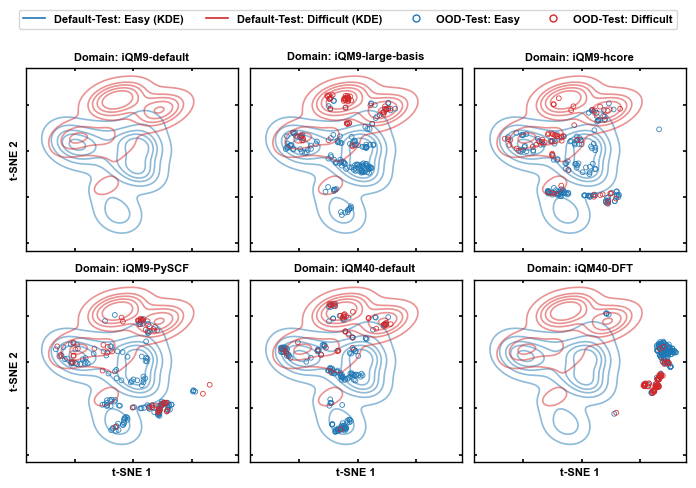

In [14]:
get_tsne_plots(X, y, domain_all_static, 'Figure_5.pdf')

### Figure 6 t-SNE Projection of Feature Space Distributions for Dynamic Approach

In [10]:
data_path = os.path.join(Path.cwd().parents[0], "notebook_data", "domain_data_dynamic.pkl")
with open(data_path, "rb") as file:
    (X, y, domain_all_dynamic) = pickle.load(file)

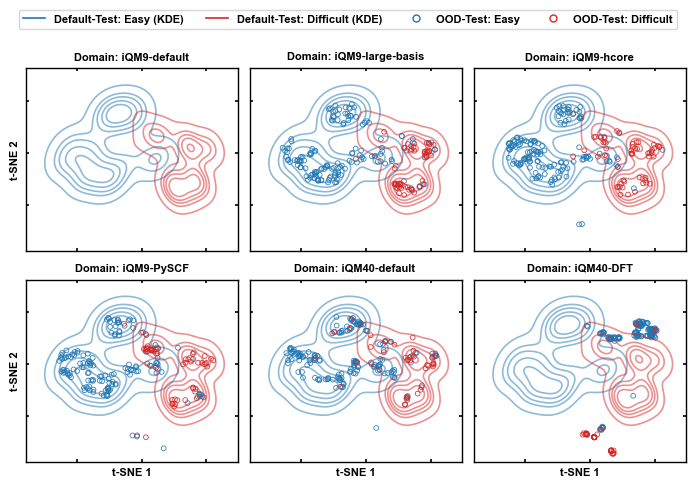

In [11]:
get_tsne_plots(X, y, domain_all_dynamic, 'Figure_6.pdf')

### Figure 7. 2D KDE of Optimal Level-Shifting Parameter Pairs Obtained Through Bayesian Optimization on the QM9-H1000

In [49]:
data_path = os.path.join(Path.cwd().parents[0], "notebook_data", "QM9H1000_optimal_shifts.csv")
df_tc_optimal = pd.read_csv(data_path)

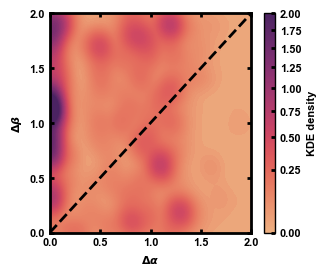

In [54]:
_set_global_font()

plt.figure(figsize=(3.25, 2.85))

# ---- Better, smoother KDE background ----
# PowerNorm (gamma < 1) stretches contrast in low values
norm = mcolors.PowerNorm(gamma=0.6, vmin=0, vmax=2)
cbar_ticks = [0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0]

ax = sns.kdeplot(
    data=df_tc_optimal,
    x='dalpha',
    y='dbeta',
    fill=True,
    bw_adjust=0.7,
    cmap='flare',         
    levels=100,           
    thresh=0,            
    cbar=False,
    norm=norm,            # emphasize differences at low values
)

# make contours blend better 
for coll in ax.collections:
    coll.set_edgecolor("face")

# Create a manual colorbar with the same norm & limits
sm = plt.cm.ScalarMappable(norm=norm, cmap='flare')
sm.set_array([])  # required dummy

cbar = plt.colorbar(
    sm,
    ax=ax,
    ticks=cbar_ticks,
)
cbar.set_label("KDE density", fontweight='bold')
cbar.ax.tick_params(width=2, direction='in')

plt.axline((0, 0), (2, 2), ls='--', c='black', lw=2)

# ---- Axis formatting ----
plt.tick_params(axis="both", direction='in', width=2,
                bottom=True, top=True, left=True, right=True)
plt.grid(False)
plt.xlabel(r'$\Delta\alpha$', fontweight='bold')
plt.ylabel(r'$\Delta\beta$', fontweight='bold')
plt.xlim(0, 2.00)
plt.ylim(0, 2.00)
plt.xticks([0, 0.5, 1, 1.5, 2], fontweight='bold')
plt.yticks([0, 0.5, 1, 1.5, 2], fontweight='bold')

for spine in plt.gca().spines.values():
    spine.set_linewidth(2)
    spine.set_color('black')

plt.savefig(
    "Figure_7.pdf",
    dpi=600, format='pdf', bbox_inches='tight'
)
plt.show()

### Figure 8. 2D KDE of Optimal Level-Shifting Pairs Obtained through Bayesian Optimization for "Difficult" Cases in the Six Test Sets

In [16]:
def plot_kde_grid_3x2(dfs, titles, vmax=None):

    _set_global_font()

    fig, axes = plt.subplots(3, 2, figsize=(3.25, 4.5), sharex=True, sharey=True)

    # Estimate a global vmax if not provided (rough upper bound)
    if vmax is None:
        vmax = 2.0

    norm = mcolors.PowerNorm(gamma=0.6, vmin=0, vmax=vmax)
    cmap_name = "flare"
    cmap = plt.get_cmap(cmap_name)

    zero_density_color = cmap(norm(0))

    # Flatten axes for easy looping
    axes_flat = axes.ravel()

    for ax, df, title in zip(axes_flat, dfs, titles):
        # KDE
        ax.set_facecolor(zero_density_color)
        sns.kdeplot(
            data=df,
            x='dalpha',
            y='dbeta',
            fill=True,
            bw_adjust=1.0,
            cmap=cmap_name,
            levels=100,
            thresh=0,
            cut=3,
            cbar=False,
            norm=norm,
            ax=ax,
        )

        # Make contours blend nicely
        for coll in ax.collections:
            coll.set_edgecolor("face")

        # Diagonal line
        ax.axline((0, 0), (2, 2), ls='--', c='black', lw=1)

        ax.set_xlim(0, 2)
        ax.set_ylim(0, 2)
        ax.set_aspect('equal')

        # Tick labels
        ax.set_xticks([0, 0.5, 1, 1.5, 2])
        ax.set_yticks([0, 0.5, 1, 1.5, 2])

        # Tick style
        ax.tick_params(axis="both", direction='in', width=2, length=1, 
                       bottom=True, top=True, left=True, right=True)

        # Thicker black frame
        for spine in ax.spines.values():
            spine.set_linewidth(2)
            spine.set_color("black")
        
        ax.set_title(title, fontweight='bold')

    # Only outer labels
    for ax in axes[-1, :]:
        ax.set_xlabel(r'$\Delta\alpha$', fontweight='bold')
    for ax in axes[:, 0]:
        ax.set_ylabel(r'$\Delta\beta$', fontweight='bold')

    # --- Shared colorbar ---
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap_name)
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=axes_flat,
        fraction=0.1,
        pad=0.02,
    )
    cbar.set_label("KDE density", fontweight='bold')
    cbar.ax.tick_params(width=2, direction='in')

    return fig, axes

In [15]:
data_path = os.path.join(Path.cwd().parents[0], "notebook_data", "Optimal_BO_test_sets.pkl")
with open(data_path, "rb") as file:
    bo_results = optimal_bo_dfs = pickle.load(file)

bo_domains = ['iQM9-default', 'iQM9-larger-basis', 'iQM9-hcore', 'iQM9-PySCF', 'iQM40-default', 'iQM40-dft']

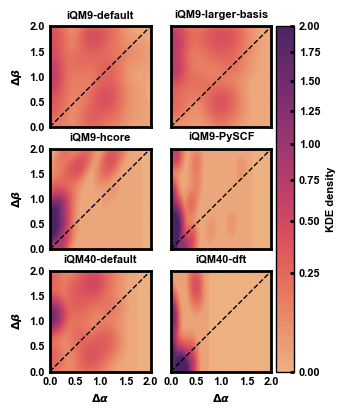

In [17]:
fig, axes = plot_kde_grid_3x2(bo_results, bo_domains, vmax=2.0)
fig.savefig(
    "Figure_8.pdf",
    dpi=600, format='pdf', bbox_inches='tight'
)
plt.show()

### Figure 9. Comparison of ML-Guided Adaptive Level-Shifting Strategies Across Six SCF Test Sets

In [18]:
data_path = os.path.join(Path.cwd().parents[0], "notebook_data", "all_calculation_results.pkl")
with open(data_path, 'rb') as file:
    merged_all, long_mol_all, total_cost_all, domain_names = pickle.load(file)

In [19]:
def plot_cost_plus_iterations_violin(
    ax_bar,
    ax_vio,
    df,
    long_molecules,
    total_cost,
    method_labels=None,
    bar_ticks=None,
    bar_tick_labels=None,
):
    if method_labels is None:
        method_labels = {
            "af": "α-DLS",
            "bf": "β-DLS",
            "ar": "α-RST",
            "br": "β-RST",
            "bo": "Optimal",
        }

    # Tag each molecule as long / short once
    df = df.copy()
    df["type"] = np.where(df["molecule"].isin(long_molecules),
                          "Long (hard)", "Short (easy)")

    # Build long-format dataframe
    rows = []
    for key, label in method_labels.items():
        iter_col = f"{key}-iters"
        if iter_col not in df.columns:
            continue

        sub = df[["molecule", "type", iter_col]].dropna().copy()
        sub.rename(columns={iter_col: "iterations"}, inplace=True)
        sub["method"] = label
        rows.append(sub)

    plot_df = pd.concat(rows, ignore_index=True)

    # ===== Top bar: total cost =====
    x = np.arange(len(method_labels))
    ax_bar.bar(x, total_cost[:len(method_labels)], color="orange")

    ax_bar.tick_params(axis="x", which="both", bottom=False, labelbottom=False)
    ax_bar.set_yscale("log")
    ax_bar.minorticks_off()

    # Ensure only major ticks are shown
    ax_bar.yaxis.set_minor_locator(plt.NullLocator())
    if bar_ticks and bar_tick_labels:
        ax_bar.set_yticks(bar_ticks)
        ax_bar.set_yticklabels(bar_tick_labels)
    ax_bar.set_yticks([100000, 1000000, 3000000])
    ax_bar.set_yticklabels([r"$10^5$", r"$10^6$", r"$3\times10^6$"])
    ax_bar.tick_params(direction="in", top=True, right=True, bottom=True, left=True, width=2, length=2, labelsize=8)

    for spine in ax_bar.spines.values():
        spine.set_linewidth(2)
        spine.set_color("black")

    # ===== Bottom: violin + points =====
    sns.violinplot(
        data=plot_df,
        x="method",
        y="iterations",
        color="white",
        inner=None,
        cut=0,
        ax=ax_vio,
    )

    sns.stripplot(
        data=plot_df[plot_df["type"] == "Short (easy)"],
        x="method",
        y="iterations",
        color="tab:blue",
        alpha=0.6,
        size=3,
        jitter=0.3,
        ax=ax_vio,
    )

    sns.stripplot(
        data=plot_df[plot_df["type"] == "Long (hard)"],
        x="method",
        y="iterations",
        color="tab:red",
        alpha=0.6,
        size=3,
        jitter=0.3,
        ax=ax_vio,
    )

    # Log scale with MAJOR ticks only
    ax_vio.set_yscale("log")

    ax_vio.set_ylabel("")
    ax_vio.set_xlabel("")

    # Turn OFF minor ticks completely
    ax_vio.minorticks_off()

    # Ensure only major ticks are shown
    ax_vio.yaxis.set_minor_locator(plt.NullLocator())

    # --- Tick appearance ---
    ax_vio.tick_params(
        axis='y',
        which='major',
        length=2,
        width=2,
        direction='in'
    )

    ax_vio.tick_params(
        axis='x',
        which='major',
        length=2,
        width=2,
        direction='in'
    )

    ax_vio.set_yticks([10, 100, 1000, 5000])
    ax_vio.set_yticklabels([r"$10^1$", r"$10^2$", r"$10^3$", r"$5\times10^3$"])

    # frame styling
    for spine in ax_vio.spines.values():
        spine.set_linewidth(2)
        spine.set_color("black")

def plot_all_domains_3x2(
    domain_dfs,
    domain_long_mols,
    domain_total_costs,
    outpath,
):

    fig, axes = plt.subplots(
        6, 2,
        figsize=(7, 7),
        sharex="col",
        sharey="row",
        gridspec_kw={"height_ratios": [1, 3] * 3,
                     "hspace": 0.1,
                     "wspace": 0.05}
    )

    for i in range(6):
        r = (i // 2) * 2
        c = i % 2

        if i == 4 or i==5:
            plot_cost_plus_iterations_violin(
            ax_bar=axes[r, c],
            ax_vio=axes[r + 1, c],
            df=domain_dfs[i],
            long_molecules=domain_long_mols[i],
            total_cost=domain_total_costs[i],
            bar_ticks=[1000, 2000, 3000],
            bar_tick_labels=[r"$10^3$", r"$2\times10^3$", r"$3\times10^3$"],
        )
        else:
            plot_cost_plus_iterations_violin(
            ax_bar=axes[r, c],
            ax_vio=axes[r + 1, c],
            df=domain_dfs[i],
            long_molecules=domain_long_mols[i],
            total_cost=domain_total_costs[i],
        )
        

    # Global labels
    axes[-1, 0].set_xlabel("Method")
    axes[-1, 1].set_xlabel("Method")

    plt.savefig(outpath, dpi=600, format='pdf', bbox_inches="tight")
    plt.show()

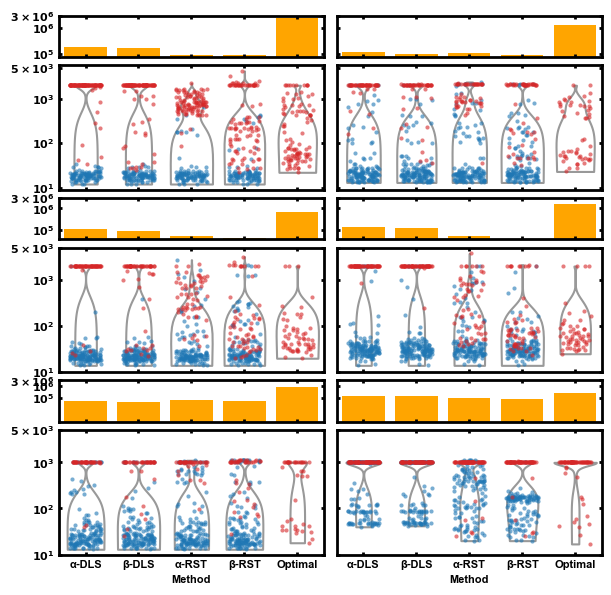

In [20]:
plot_all_domains_3x2(merged_all, long_mol_all, total_cost_all, 'Figure_9.pdf')

### Figure 10 Outcome-dependent effects of β-RST on intermediate convergence cases

In [21]:
data_path = os.path.join(Path.cwd().parents[0], "notebook_data", "intermediate_deployment_results.csv")

data = pd.read_csv(data_path)

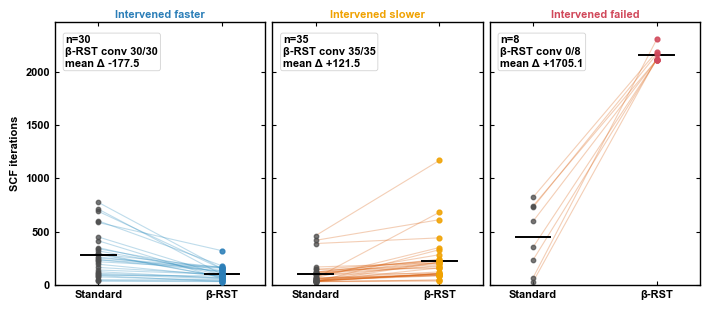

In [23]:
intervened = data[data["ml_restart_triggered"]].copy()

panels = [
    ("accelerated_standard_success", "Intervened faster", "#2C7FB8"),
    ("slower_than_standard_success", "Intervened slower", "#F0A202"),
    ("harmed_standard_success", "Intervened failed", "#D1495B"),
]

_set_global_font()

fig, axes = plt.subplots(1, 3, figsize=(7, 3), sharey=True)

ymax = float(
    intervened[
        [
            "standard_iterations_no_intervention",
            "ml_guided_iterations_with_intervention",
        ]
    ]
    .max()
    .max()
)

for ax, (outcome, panel_label, color) in zip(axes, panels):
    sub = intervened[
        intervened["outcome_vs_no_intervention"] == outcome
    ].sort_values("delta_iterations_ml_minus_standard")

    for _, row in sub.iterrows():
        delta = row["delta_iterations_ml_minus_standard"]
        line_color = "#2B8CBE" if delta < 0 else "#D95F0E"

        ax.plot(
            [0, 1],
            [
                row["standard_iterations_no_intervention"],
                row["ml_guided_iterations_with_intervention"],
            ],
            color=line_color,
            alpha=0.30,
            linewidth=0.8,
            zorder=1,
        )

    ax.scatter(
        np.zeros(len(sub)),
        sub["standard_iterations_no_intervention"],
        s=10,
        color="#4D4D4D",
        alpha=0.75,
        zorder=2,
    )
    ax.scatter(
        np.ones(len(sub)),
        sub["ml_guided_iterations_with_intervention"],
        s=12,
        color=color,
        alpha=0.88,
        zorder=3,
    )

    standard_mean = float(sub["standard_iterations_no_intervention"].mean())
    ml_mean = float(sub["ml_guided_iterations_with_intervention"].mean())

    ax.plot([-0.14, 0.14], [standard_mean, standard_mean], color="black", linewidth=1.4)
    ax.plot([0.86, 1.14], [ml_mean, ml_mean], color="black", linewidth=1.4)

    n = len(sub)
    ml_converged = int(sub["ml_guided_converged_with_intervention"].sum())
    mean_delta = float(sub["delta_iterations_ml_minus_standard"].mean())

    ax.text(
        0.05,
        0.95,
        f"n={n}\nβ-RST conv {ml_converged}/{n}\nmean Δ {mean_delta:+.1f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=8,
        fontfamily="Arial",
        fontweight="bold",
        bbox={
            "boxstyle": "round,pad=0.20",
            "facecolor": "white",
            "edgecolor": "#D0D0D0",
            "linewidth": 0.6,
            "alpha": 0.94,
        },
    )

    ax.set_title(panel_label, fontweight="bold", fontsize=8, color=color, pad=3)
    ax.set_xlim(-0.35, 1.35)
    ax.set_ylim(0, ymax * 1.07)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Standard", "β-RST"], fontweight="bold", fontsize=8)
    ax.tick_params(
        axis="both",
        which="both",
        direction="in",
        labelsize=8,
        width=0.8,
        length=3,
        top=True,
        right=True,
        left=True,
        bottom=True,
    )
    ax.grid(False)

axes[0].set_ylabel("SCF iterations", fontweight="bold", fontsize=8)

fig.tight_layout(pad=0.45, w_pad=0.65)
fig.savefig('Figure_10.pdf', dpi=600, bbox_inches="tight")

plt.show()